# APTCODER — Junior Software Engineer (Python + AIML)
## ML Assignment Submission

| | |
|---|---|
| **Role** | Junior Software Engineer (Python + AIML) |
| **Sections** | A: Data Understanding · B: Supervised Learning · C: Unsupervised Learning · D: Recommendation & Analytics |
| **Tools** | Python, NumPy, Pandas, Scikit-learn, Matplotlib |

---


In [1]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, 
                              confusion_matrix,
                              silhouette_score)
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import (MinMaxScaler, 
                                   StandardScaler)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from scipy.spatial.distance import euclidean

print("All libraries imported successfully")


All libraries imported successfully


---
## Section A: Data Understanding & Preprocessing (Q1–Q5)


### Q1 — Mean, Median, Standard Deviation

In [2]:
scores = [40, 50, 60, 70, 80]

mean   = np.mean(scores)
median = np.median(scores)
std    = np.std(scores)

print("Quiz Scores:", scores)
print(f"Mean:               {mean}")
print(f"Median:             {median}")
print(f"Standard Deviation: {std:.2f}")
print()
print("Interpretation:")
print(f"  → Average score is {mean} marks")
print(f"  → Middle value is {median} marks")
print(f"  → Scores deviate by ±{std:.2f} from the mean")


Quiz Scores: [40, 50, 60, 70, 80]
Mean:               60.0
Median:             60.0
Standard Deviation: 14.14

Interpretation:
  → Average score is 60.0 marks
  → Middle value is 60.0 marks
  → Scores deviate by ±14.14 from the mean


### Q2 — Min-Max Normalization

In [3]:
attendance = [60, 65, 70, 85, 95]

x_min = min(attendance)
x_max = max(attendance)

normalized = [(x - x_min) / (x_max - x_min) 
              for x in attendance]

print("Original Attendance:", attendance)
print("Normalized Values:  ", [round(v, 2) for v in normalized])
print()
print("Verification using sklearn:")
scaler = MinMaxScaler()
sk_norm = scaler.fit_transform(
    np.array(attendance).reshape(-1,1)
).flatten()
print("Sklearn Normalized: ", [round(v, 2) for v in sk_norm])
print()
print("Interpretation:")
print(f"  → {x_min}% (lowest) maps to 0.0")
print(f"  → {x_max}% (highest) maps to 1.0")


Original Attendance: [60, 65, 70, 85, 95]
Normalized Values:   [0.0, 0.14, 0.29, 0.71, 1.0]

Verification using sklearn:
Sklearn Normalized:  [np.float64(0.0), np.float64(0.14), np.float64(0.29), np.float64(0.71), np.float64(1.0)]

Interpretation:
  → 60% (lowest) maps to 0.0
  → 95% (highest) maps to 1.0


### Q3 — Class Imbalance

In [4]:
passed = 800
failed = 200
total  = passed + failed

ratio     = passed / failed
pass_pct  = (passed / total) * 100
fail_pct  = (failed / total) * 100

print(f"Total Students:        {total}")
print(f"Passed:                {passed} ({pass_pct:.0f}%)")
print(f"Failed:                {failed} ({fail_pct:.0f}%)")
print(f"Class Imbalance Ratio: {ratio:.1f}:1")
print()
print("Interpretation:")
print(f"  → For every 1 failed student, {ratio:.0f} passed")
print(f"  → A model predicting 'Pass' always = {pass_pct:.0f}% accuracy")
print(f"  → But it would miss ALL {failed} failing students!")
print(f"  → Fix: use SMOTE, class weights, or F1-score evaluation")


Total Students:        1000
Passed:                800 (80%)
Failed:                200 (20%)
Class Imbalance Ratio: 4.0:1

Interpretation:
  → For every 1 failed student, 4 passed
  → A model predicting 'Pass' always = 80% accuracy
  → But it would miss ALL 200 failing students!
  → Fix: use SMOTE, class weights, or F1-score evaluation


### Q4 — Linear Regression Slope

Study Hours vs Score Data:
  Hours:  [2, 4, 6]
  Scores: [50, 60, 70]

Calculated Slope (m): 5.0

Verification using sklearn:
Sklearn Slope:        4.999999999999998

Interpretation:
  → Every extra hour of study = +5 marks


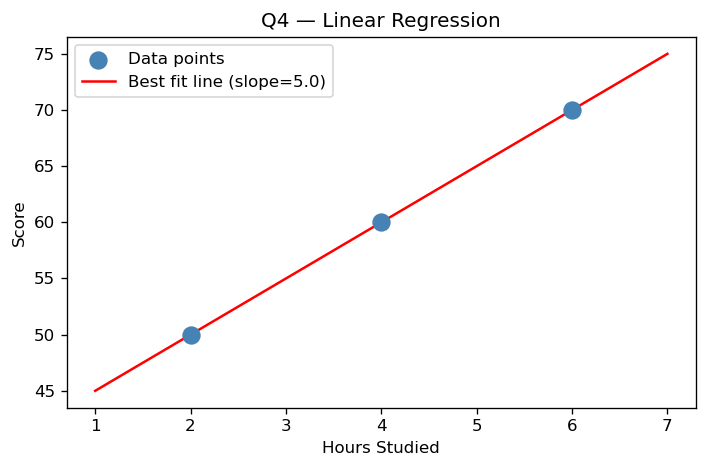

In [5]:
hours  = [2, 4, 6]
scores = [50, 60, 70]
n      = len(hours)

sum_x  = sum(hours)
sum_y  = sum(scores)
sum_xy = sum(x*y for x, y in zip(hours, scores))
sum_x2 = sum(x**2 for x in hours)

slope = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)

print("Study Hours vs Score Data:")
print(f"  Hours:  {hours}")
print(f"  Scores: {scores}")
print()
print(f"Calculated Slope (m): {slope}")
print()
print("Verification using sklearn:")
X = np.array(hours).reshape(-1, 1)
y = np.array(scores)
model = LinearRegression()
model.fit(X, y)
print(f"Sklearn Slope:        {model.coef_[0]}")
print()
print(f"Interpretation:")
print(f"  → Every extra hour of study = +{slope:.0f} marks")

# plot
plt.figure(figsize=(6, 4))
plt.scatter(hours, scores, color='steelblue', 
            s=100, zorder=5, label='Data points')
x_line = np.linspace(1, 7, 100)
y_line = model.predict(x_line.reshape(-1,1))
plt.plot(x_line, y_line, 'r-', 
         label=f'Best fit line (slope={slope})')
plt.xlabel('Hours Studied')
plt.ylabel('Score')
plt.title('Q4 — Linear Regression')
plt.legend()
plt.tight_layout()
plt.show()


### Q5 — Mean Imputation

In [6]:
data = [80, None, 70, None, 90]

known    = [x for x in data if x is not None]
mean_val = sum(known) / len(known)
filled   = [x if x is not None else mean_val for x in data]

print("Original Data:", data)
print(f"Mean of known values: {mean_val}")
print("After Imputation:    ", filled)
print()
print("Verification using sklearn:")
data_np  = np.array([80, np.nan, 70, np.nan, 90]).reshape(-1,1)
imputer  = SimpleImputer(strategy='mean')
sk_filled = imputer.fit_transform(data_np).flatten()
print("Sklearn Imputed:     ", sk_filled.tolist())
print()
print("Interpretation:")
print(f"  → Missing values replaced with mean = {mean_val}")
print(f"  → Use median imputation if outliers exist")


Original Data: [80, None, 70, None, 90]
Mean of known values: 80.0
After Imputation:     [80, 80.0, 70, 80.0, 90]

Verification using sklearn:
Sklearn Imputed:      [80.0, 80.0, 70.0, 80.0, 90.0]

Interpretation:
  → Missing values replaced with mean = 80.0
  → Use median imputation if outliers exist


---
## Section B: Supervised Learning (Q6–Q13)


### Q6 — Logistic Regression Threshold

In [7]:
probability = 0.72
threshold   = 0.6

prediction = "Dropout" if probability >= threshold else "Not Dropout"

print(f"Dropout Probability: {probability}")
print(f"Threshold:           {threshold}")
print(f"Prediction:          {prediction}")
print()
print("Interpretation:")
print(f"  → {probability} >= {threshold} → classified as {prediction}")
print(f"  → Lower threshold catches more at-risk students")
print(f"  → but increases false alarms")


Dropout Probability: 0.72
Threshold:           0.6
Prediction:          Dropout

Interpretation:
  → 0.72 >= 0.6 → classified as Dropout
  → Lower threshold catches more at-risk students
  → but increases false alarms


### Q7 — Confusion Matrix Metrics

In [8]:
TP = 70  # Actual Pass, Predicted Pass
FN = 10  # Actual Pass, Predicted Fail
FP = 5   # Actual Fail, Predicted Pass
TN = 15  # Actual Fail, Predicted Fail

total     = TP + FN + FP + TN
accuracy  = (TP + TN) / total
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
f1        = 2 * (precision * recall) / (precision + recall)

print("Confusion Matrix:")
print(f"{'':20} Predicted Pass  Predicted Fail")
print(f"{'Actual Pass':20} {TP:<16} {FN}")
print(f"{'Actual Fail':20} {FP:<16} {TN}")
print()
print(f"Accuracy:  {accuracy  * 100:.1f}%")
print(f"Precision: {precision * 100:.1f}%")
print(f"Recall:    {recall    * 100:.1f}%")
print(f"F1 Score:  {f1        * 100:.1f}%")
print()
print("Interpretation:")
print(f"  → Accuracy:  {accuracy*100:.1f}% overall correct predictions")
print(f"  → Precision: {precision*100:.1f}% of predicted Pass are actually Pass")
print(f"  → Recall:    {recall*100:.1f}% of actual Pass were correctly found")
print(f"  → F1 Score:  {f1*100:.1f}% harmonic mean — best for imbalanced data")


Confusion Matrix:
                     Predicted Pass  Predicted Fail
Actual Pass          70               10
Actual Fail          5                15

Accuracy:  85.0%
Precision: 93.3%
Recall:    87.5%
F1 Score:  90.3%

Interpretation:
  → Accuracy:  85.0% overall correct predictions
  → Precision: 93.3% of predicted Pass are actually Pass
  → Recall:    87.5% of actual Pass were correctly found
  → F1 Score:  90.3% harmonic mean — best for imbalanced data


### Q8 — KNN Classification

In [9]:
neighbors = [
    (0.5, 'Pass'),
    (0.7, 'Fail'),
    (0.9, 'Pass')
]
k = 3

k_nearest = sorted(neighbors, key=lambda x: x[0])[:k]
labels    = [label for _, label in k_nearest]
vote      = Counter(labels).most_common(1)[0][0]

print(f"K = {k}")
print()
print("Neighbors (sorted by distance):")
for dist, label in k_nearest:
    print(f"  Distance: {dist} → Label: {label}")
print()
print(f"Vote count: {dict(Counter(labels))}")
print(f"Prediction: {vote}")
print()
print("Interpretation:")
print(f"  → 2 Pass vs 1 Fail → majority wins → {vote}")


K = 3

Neighbors (sorted by distance):
  Distance: 0.5 → Label: Pass
  Distance: 0.7 → Label: Fail
  Distance: 0.9 → Label: Pass

Vote count: {'Pass': 2, 'Fail': 1}
Prediction: Pass

Interpretation:
  → 2 Pass vs 1 Fail → majority wins → Pass


### Q9 — Gini Impurity

In [10]:
def gini_impurity(p_pass, p_fail):
    return 1 - (p_pass**2 + p_fail**2)

total        = 100
group1_size  = 60   # attendance > 75%
group2_size  = 40   # attendance <= 75%

# equal distribution assumed (50-50)
gini1 = gini_impurity(0.5, 0.5)
gini2 = gini_impurity(0.5, 0.5)

weighted_gini = ((group1_size / total) * gini1 + 
                 (group2_size / total) * gini2)

print("Decision Tree Split: Attendance > 75%")
print()
print(f"Group 1 (attendance > 75%):  {group1_size} students")
print(f"Group 2 (attendance <= 75%): {group2_size} students")
print()
print(f"Gini Group 1: {gini1}")
print(f"Gini Group 2: {gini2}")
print(f"Weighted Gini Impurity: {weighted_gini}")
print()
print("Interpretation:")
print(f"  → Gini = 0.5 means maximum impurity (50-50 split)")
print(f"  → This split did not help separate Pass/Fail students")
print(f"  → Tree would look for a better split feature")


Decision Tree Split: Attendance > 75%

Group 1 (attendance > 75%):  60 students
Group 2 (attendance <= 75%): 40 students

Gini Group 1: 0.5
Gini Group 2: 0.5
Weighted Gini Impurity: 0.5

Interpretation:
  → Gini = 0.5 means maximum impurity (50-50 split)
  → This split did not help separate Pass/Fail students
  → Tree would look for a better split feature


### Q10 — Mean Absolute Error (MAE)

In [11]:
actual    = [80, 85, 90]
predicted = [78, 88, 92]

errors = [abs(a - p) for a, p in zip(actual, predicted)]
mae    = sum(errors) / len(errors)

print("Actual vs Predicted Scores:")
for i, (a, p, e) in enumerate(zip(actual, predicted, errors)):
    print(f"  Student {i+1}: actual={a}, predicted={p}, error={e}")
print()
print(f"MAE (manual):  {mae:.2f}")
print(f"MAE (sklearn): {mean_absolute_error(actual, predicted):.2f}")
print()
print("Interpretation:")
print(f"  → On average, predictions are {mae:.2f} marks off")
print(f"  → Lower MAE = better model performance")


Actual vs Predicted Scores:
  Student 1: actual=80, predicted=78, error=2
  Student 2: actual=85, predicted=88, error=3
  Student 3: actual=90, predicted=92, error=2

MAE (manual):  2.33
MAE (sklearn): 2.33

Interpretation:
  → On average, predictions are 2.33 marks off
  → Lower MAE = better model performance


### Q11 — Random Forest Improvement

Single Decision Tree Accuracy: 60%
Random Forest Accuracy:        78%
Absolute Gain:                 +18%
Relative Improvement:          +30.0%

Why Random Forest outperforms single tree:
  → Uses 100 diverse trees trained on random data subsets
  → Each tree votes → majority wins → reduces errors
  → Reduces overfitting through ensemble averaging


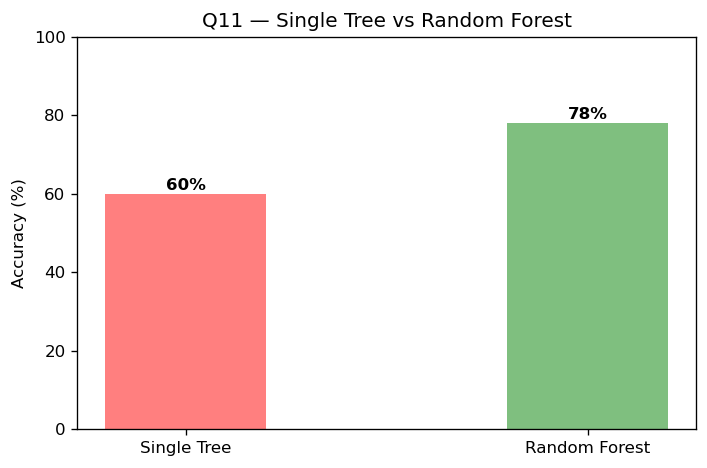

In [12]:
single_tree_accuracy = 60
ensemble_accuracy    = 78

absolute_gain   = ensemble_accuracy - single_tree_accuracy
improvement_pct = (absolute_gain / single_tree_accuracy) * 100

print(f"Single Decision Tree Accuracy: {single_tree_accuracy}%")
print(f"Random Forest Accuracy:        {ensemble_accuracy}%")
print(f"Absolute Gain:                 +{absolute_gain}%")
print(f"Relative Improvement:          +{improvement_pct:.1f}%")
print()
print("Why Random Forest outperforms single tree:")
print("  → Uses 100 diverse trees trained on random data subsets")
print("  → Each tree votes → majority wins → reduces errors")
print("  → Reduces overfitting through ensemble averaging")

# visualization
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Single Tree', 'Random Forest'], 
               [single_tree_accuracy, ensemble_accuracy],
               color=['#ff7f7f', '#7fbf7f'],
               width=0.4)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Q11 — Single Tree vs Random Forest')
ax.set_ylim(0, 100)
for bar, val in zip(bars, 
                    [single_tree_accuracy, ensemble_accuracy]):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 1,
            f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


### Q12 — Threshold to Labels

In [13]:
import numpy as np

probabilities = np.array([0.2, 0.4, 0.6, 0.9])
threshold     = 0.5

labels = (probabilities >= threshold).astype(int)

print(f"Threshold: {threshold}")
print()
print("Classification Results:")
for i, (p, l) in enumerate(zip(probabilities, labels)):
    label_str = "Dropout" if l == 1 else "Not Dropout"
    print(f"  Student {i+1}: probability={p} → {label_str} ({l})")
print()
print(f"Predicted Labels: {labels.tolist()}")
print()
print("Interpretation:")
print("  → Probabilities below 0.5 → Not Dropout (0)")
print("  → Probabilities above 0.5 → Dropout (1)")


Threshold: 0.5

Classification Results:
  Student 1: probability=0.2 → Not Dropout (0)
  Student 2: probability=0.4 → Not Dropout (0)
  Student 3: probability=0.6 → Dropout (1)
  Student 4: probability=0.9 → Dropout (1)

Predicted Labels: [0, 0, 1, 1]

Interpretation:
  → Probabilities below 0.5 → Not Dropout (0)
  → Probabilities above 0.5 → Dropout (1)


### Q13 — Feature Importance (80% Rule)

Feature Importance Analysis:

Feature         Importance   Cumulative
----------------------------------------
Quiz Score             0.5         0.5
Attendance             0.3         0.8 ← 80% reached

Features contributing 80% importance: ['Quiz Score', 'Attendance']

Interpretation (Pareto Principle):
  → 80% of prediction power from 20% of features
  → Drop 'Time Spent' → simpler, faster model
  → Focus data collection on Quiz Score & Attendance


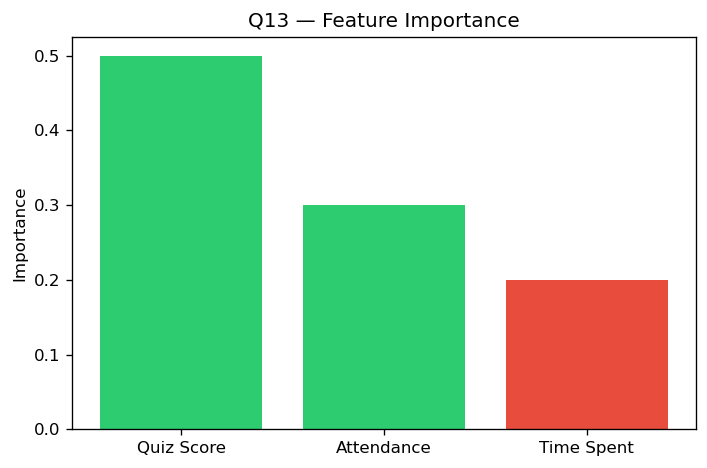

In [14]:
import matplotlib.pyplot as plt

features = {
    'Quiz Score': 0.5,
    'Attendance': 0.3,
    'Time Spent': 0.2
}

sorted_features = sorted(features.items(), key=lambda x: x[1], reverse=True)

cumulative = 0
selected   = []
threshold  = 0.80

print("Feature Importance Analysis:\n")
print(f"{'Feature':<15} {'Importance':>10} {'Cumulative':>12}")
print("-" * 40)

for feature, importance in sorted_features:
    cumulative += importance
    selected.append(feature)
    marker = " ← 80% reached" if abs(cumulative - 0.8) < 0.01 else ""
    print(f"{feature:<15} {importance:>10.1f} {cumulative:>11.1f}{marker}")
    if cumulative >= threshold:
        break

print()
print(f"Features contributing 80% importance: {selected}")
print()
print("Interpretation (Pareto Principle):")
print("  → 80% of prediction power from 20% of features")
print("  → Drop 'Time Spent' → simpler, faster model")
print("  → Focus data collection on Quiz Score & Attendance")

# Visualization
plt.figure(figsize=(6, 4))
names  = [f[0] for f in sorted_features]
vals   = [f[1] for f in sorted_features]
colors = ['#2ecc71' if n in selected else '#e74c3c' for n in names]
plt.bar(names, vals, color=colors)
plt.ylabel('Importance')
plt.title('Q13 — Feature Importance')
plt.axhline(y=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

---
## Section C: Unsupervised Learning (Q14–Q20)


### Q14 — K-Means Clustering

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K-Means Clustering (K=2)

  Student 1: score=45 → Cluster 1
  Student 2: score=50 → Cluster 1
  Student 3: score=90 → Cluster 2
  Student 4: score=95 → Cluster 2

Final Centroids:
  Cluster 1 centroid: 47.5
  Cluster 2 centroid: 92.5

Interpretation:
  → Cluster 1: Low scorers  [45, 50] — needs support
  → Cluster 2: High scorers [90, 95] — advanced group


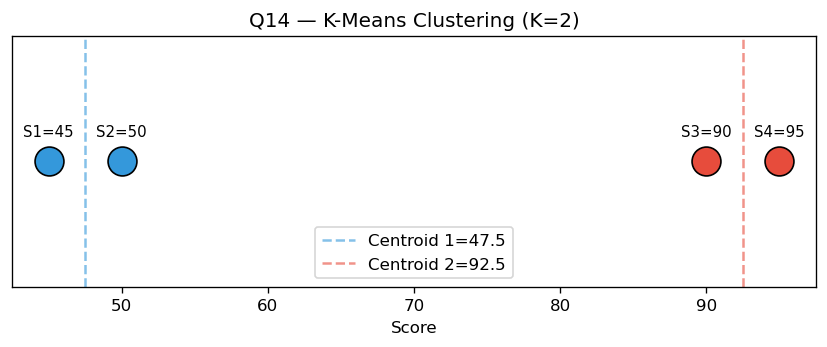

In [15]:
from sklearn.cluster import KMeans
import numpy as np

scores = np.array([45, 50, 90, 95]).reshape(-1, 1)

kmeans    = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(scores)

labels    = kmeans.labels_
centroids = kmeans.cluster_centers_.flatten()

print("K-Means Clustering (K=2)")
print()
for i, (score, label) in enumerate(zip(scores.flatten(), labels)):
    print(f"  Student {i+1}: score={score} → Cluster {label+1}")
print()
print(f"Final Centroids:")
print(f"  Cluster 1 centroid: {centroids[0]}")
print(f"  Cluster 2 centroid: {centroids[1]}")
print()
print("Interpretation:")
print("  → Cluster 1: Low scorers  [45, 50] — needs support")
print("  → Cluster 2: High scorers [90, 95] — advanced group")

# visualization
plt.figure(figsize=(7, 3))
colors = ['#3498db', '#e74c3c']
for i, (score, label) in enumerate(zip(scores.flatten(), labels)):
    plt.scatter(score, 0, color=colors[label], s=300, 
                zorder=5, edgecolors='black')
    plt.annotate(f'S{i+1}={score}', (score, 0),
                 textcoords="offset points", xytext=(0,15),
                 ha='center', fontsize=9)
for i, c in enumerate(centroids):
    plt.axvline(x=c, color=colors[i], linestyle='--', 
                alpha=0.6, label=f'Centroid {i+1}={c}')
plt.xlabel('Score')
plt.title('Q14 — K-Means Clustering (K=2)')
plt.legend()
plt.yticks([])
plt.tight_layout()
plt.show()


### Q15 — Euclidean Distance

In [16]:
import numpy as np

A = np.array([2, 80])
B = np.array([4, 90])

diff     = B - A
squared  = diff ** 2
distance = np.sqrt(np.sum(squared))

print("Euclidean Distance Calculation:")
print(f"  Student A: {A}")
print(f"  Student B: {B}")
print()
print(f"  Difference:       {diff}")
print(f"  Squared:          {squared}")
print(f"  Sum of squares:   {np.sum(squared)}")
print(f"  Distance (√{np.sum(squared)}): {distance:.4f}")
print()
print(f"Verification — numpy:  {np.linalg.norm(B-A):.4f}")
print(f"Verification — scipy:  {euclidean(A, B):.4f}")
print()
print("Interpretation:")
print(f"  → Distance between students = {distance:.2f}")
print(f"  → Closer distance = more similar students")


Euclidean Distance Calculation:
  Student A: [ 2 80]
  Student B: [ 4 90]

  Difference:       [ 2 10]
  Squared:          [  4 100]
  Sum of squares:   104
  Distance (√104): 10.1980

Verification — numpy:  10.1980
Verification — scipy:  10.1980

Interpretation:
  → Distance between students = 10.20
  → Closer distance = more similar students


### Q16 — Centroid Assignment

In [17]:
import numpy as np

C1      = np.array([50, 5])
C2      = np.array([90, 9])
student = np.array([60, 6])

dist_C1 = np.linalg.norm(student - C1)
dist_C2 = np.linalg.norm(student - C2)

assigned = "C1" if dist_C1 < dist_C2 else "C2"

print(f"Centroids:")
print(f"  C1 = {C1}")
print(f"  C2 = {C2}")
print(f"  Student = {student}")
print()
print(f"Distance to C1: {dist_C1:.4f}")
print(f"Distance to C2: {dist_C2:.4f}")
print()
print(f"Assigned to: {assigned}")
print()
print("Interpretation:")
print(f"  → Student (60,6) is much closer to C1 (50,5)")
print(f"  → Belongs to the lower-performing cluster")


Centroids:
  C1 = [50  5]
  C2 = [90  9]
  Student = [60  6]

Distance to C1: 10.0499
Distance to C2: 30.1496

Assigned to: C1

Interpretation:
  → Student (60,6) is much closer to C1 (50,5)
  → Belongs to the lower-performing cluster


### Q17 — Elbow Method

Elbow Method Analysis:
K     Inertia    Drop       % Drop
----------------------------------------
1     500        —          —
2     200        300        60.0%
3     180        20         10.0%

Optimal K (elbow): 2

Interpretation:
  → K=1 → K=2: massive drop of 300 (60%)
  → K=2 → K=3: tiny drop of 20 (10%)
  → Elbow at K=2 → best number of clusters


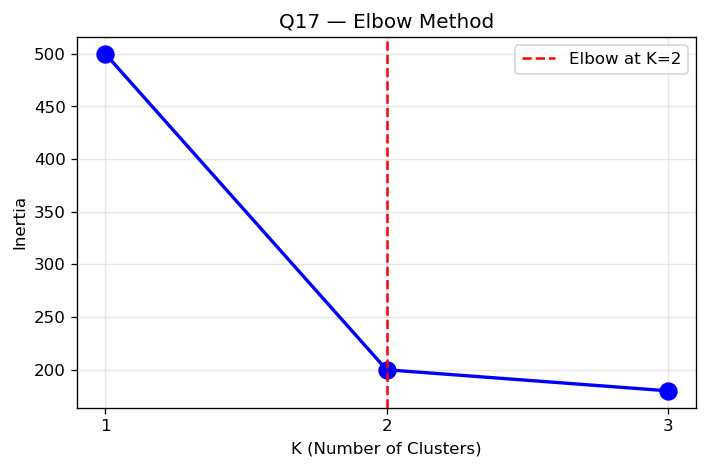

In [18]:
k_values = [1, 2, 3]
inertias = [500, 200, 180]

print("Elbow Method Analysis:")
print(f"{'K':<5} {'Inertia':<10} {'Drop':<10} {'% Drop'}")
print("-" * 40)

drops = []
for i in range(len(k_values)):
    if i == 0:
        print(f"{k_values[i]:<5} {inertias[i]:<10} {'—':<10} —")
    else:
        drop     = inertias[i-1] - inertias[i]
        pct_drop = (drop / inertias[i-1]) * 100
        drops.append((k_values[i], drop))
        print(f"{k_values[i]:<5} {inertias[i]:<10} "
              f"{drop:<10} {pct_drop:.1f}%")

best_k = max(drops, key=lambda x: x[1])[0]
print()
print(f"Optimal K (elbow): {best_k}")
print()
print("Interpretation:")
print(f"  → K=1 → K=2: massive drop of 300 (60%)")
print(f"  → K=2 → K=3: tiny drop of 20 (10%)")
print(f"  → Elbow at K=2 → best number of clusters")

# visualization
plt.figure(figsize=(6, 4))
plt.plot(k_values, inertias, 'bo-', 
         linewidth=2, markersize=10)
plt.axvline(x=best_k, color='red', linestyle='--',
            label=f'Elbow at K={best_k}')
plt.xlabel('K (Number of Clusters)')
plt.ylabel('Inertia')
plt.title('Q17 — Elbow Method')
plt.xticks(k_values)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Q18 — DBSCAN Point Classification

In [19]:
eps             = 5
min_samples     = 3
neighbors_count = 2
near_core_point = False   # not stated in question

def classify_point(neighbors, min_samples, near_core=False):
    if neighbors >= min_samples:
        return "Core Point"
    elif near_core:
        return "Border Point"
    else:
        return "Noise"

result = classify_point(
    neighbors=neighbors_count,
    min_samples=min_samples,
    near_core=near_core_point
)

print("DBSCAN Point Classification:")
print(f"  eps:             {eps}")
print(f"  min_samples:     {min_samples}")
print(f"  Point A neighbors within eps: {neighbors_count}")
print()
print(f"  Is Core Point?   "
      f"{'Yes' if neighbors_count >= min_samples else 'No'} "
      f"(needs >= {min_samples} neighbors, has {neighbors_count})")
print(f"  Near Core Point? {near_core_point}")
print()
print(f"  Classification: {result}")
print()
print("DBSCAN Point Types Summary:")
print("  Core Point   → >= min_samples neighbors within eps")
print("  Border Point → < min_samples but near a core point")
print("  Noise        → isolated, not near any core point")


DBSCAN Point Classification:
  eps:             5
  min_samples:     3
  Point A neighbors within eps: 2

  Is Core Point?   No (needs >= 3 neighbors, has 2)
  Near Core Point? False

  Classification: Noise

DBSCAN Point Types Summary:
  Core Point   → >= min_samples neighbors within eps
  Border Point → < min_samples but near a core point
  Noise        → isolated, not near any core point


### Q19 — PCA Variance Explained

PCA Variance Analysis:
Component      Eigenvalue   Variance %   Cumulative %
----------------------------------------------------
PC1                     5        50.0%          50.0%
PC2                     3        30.0%          80.0% ← 80%
PC3                     1        10.0%          90.0%
PC4                     1        10.0%         100.0%

First 2 components explain: 80.0% of variance

Interpretation:
  → PC1 captures 50% of all information
  → PC1 + PC2 = 80% → can reduce to 2D
  → PC3 and PC4 add only 10% each → can be dropped


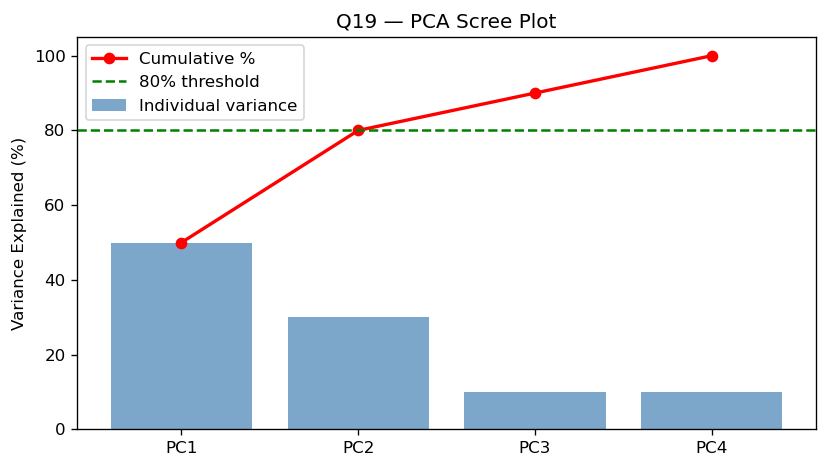

In [20]:
eigenvalues = [5, 3, 1, 1]
total       = sum(eigenvalues)

variance_explained = [(e / total) * 100 for e in eigenvalues]
cumulative         = np.cumsum(variance_explained)

print("PCA Variance Analysis:")
print(f"{'Component':<12} {'Eigenvalue':>12} "
      f"{'Variance %':>12} {'Cumulative %':>14}")
print("-" * 52)

for i, (eig, var, cum) in enumerate(
        zip(eigenvalues, variance_explained, cumulative)):
    marker = " ← 80%" if i == 1 else ""
    print(f"PC{i+1:<10} {eig:>12} "
          f"{var:>11.1f}% {cum:>13.1f}%{marker}")

print()
print(f"First 2 components explain: {cumulative[1]:.1f}% of variance")
print()
print("Interpretation:")
print("  → PC1 captures 50% of all information")
print("  → PC1 + PC2 = 80% → can reduce to 2D")
print("  → PC3 and PC4 add only 10% each → can be dropped")

# visualization
plt.figure(figsize=(7, 4))
components = [f'PC{i+1}' for i in range(len(eigenvalues))]
plt.bar(components, variance_explained, 
        alpha=0.7, color='steelblue',
        label='Individual variance')
plt.plot(components, cumulative, 
         'ro-', linewidth=2, label='Cumulative %')
plt.axhline(y=80, color='green', linestyle='--',
            label='80% threshold')
plt.ylabel('Variance Explained (%)')
plt.title('Q19 — PCA Scree Plot')
plt.legend()
plt.tight_layout()
plt.show()


### Q20 — PCA Mean Point

PCA Reduced Data:
  Student 1: (PC1=2, PC2=1)
  Student 2: (PC1=3, PC2=1)
  Student 3: (PC1=4, PC2=2)

Mean PC1: 3.0000
Mean PC2: 1.3333
Mean Point: (3.00, 1.3333)

Interpretation:
  → Mean point = center of all students in PCA space
  → Students far from (3.00, 1.33) are unusual/outliers


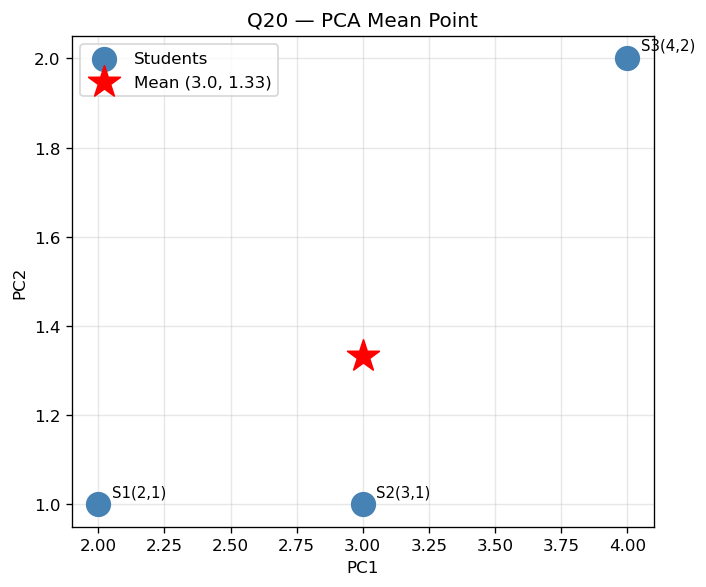

In [21]:
PC1 = [2, 3, 4]
PC2 = [1, 1, 2]

mean_PC1 = np.mean(PC1)
mean_PC2 = np.mean(PC2)

print("PCA Reduced Data:")
for i, (p1, p2) in enumerate(zip(PC1, PC2)):
    print(f"  Student {i+1}: (PC1={p1}, PC2={p2})")
print()
print(f"Mean PC1: {mean_PC1:.4f}")
print(f"Mean PC2: {mean_PC2:.4f}")
print(f"Mean Point: ({mean_PC1:.2f}, {mean_PC2:.4f})")
print()
print("Interpretation:")
print(f"  → Mean point = center of all students in PCA space")
print(f"  → Students far from ({mean_PC1:.2f}, "
      f"{mean_PC2:.2f}) are unusual/outliers")

# visualization
plt.figure(figsize=(6, 5))
plt.scatter(PC1, PC2, color='steelblue', 
            s=200, zorder=5, label='Students')
for i, (x, y) in enumerate(zip(PC1, PC2)):
    plt.annotate(f'S{i+1}({x},{y})', (x, y),
                 textcoords="offset points",
                 xytext=(8, 5), fontsize=9)
plt.scatter(mean_PC1, mean_PC2, color='red', 
            s=400, zorder=6, marker='*',
            label=f'Mean ({mean_PC1:.1f}, {mean_PC2:.2f})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Q20 — PCA Mean Point')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Section D: Recommendation & Analytics (Q21–Q25)


### Q21 — Content-Based Recommendation

In [22]:
watch_history = {
    'Python': 5,
    'AI':     2,
    'Math':   1
}

recommended = max(watch_history, key=watch_history.get)

print("Student Watch History:")
for subject, count in sorted(watch_history.items(),
                              key=lambda x: x[1],
                              reverse=True):
    bar = '█' * count
    print(f"  {subject:<10}: {bar} ({count} views)")
print()
print(f"Recommendation: {recommended}")
print()
print("Interpretation:")
print(f"  → {recommended} has highest engagement (5 views)")
print(f"  → Content-based filtering recommends similar content")
print(f"  → Next: recommend advanced Python topics")


Student Watch History:
  Python    : █████ (5 views)
  AI        : ██ (2 views)
  Math      : █ (1 views)

Recommendation: Python

Interpretation:
  → Python has highest engagement (5 views)
  → Content-based filtering recommends similar content
  → Next: recommend advanced Python topics


### Q22 — Cosine Similarity

In [23]:
import numpy as np

S1 = np.array([5, 4, 0])
S2 = np.array([4, 5, 1])

dot_product  = np.dot(S1, S2)
magnitude_S1 = np.linalg.norm(S1)
magnitude_S2 = np.linalg.norm(S2)
cosine_sim   = dot_product / (magnitude_S1 * magnitude_S2)

print("Cosine Similarity Calculation:")
print(f"  S1 = {S1}")
print(f"  S2 = {S2}")
print()
print(f"  Dot Product:   {dot_product}")
print(f"  |S1|:          {magnitude_S1:.4f}")
print(f"  |S2|:          {magnitude_S2:.4f}")
print(f"  Cosine Sim:    {cosine_sim:.4f}")
print()
print(f"Verification (sklearn): "
      f"{cosine_similarity([S1],[S2])[0][0]:.4f}")
print()
print("Interpretation:")
print(f"  → Score of {cosine_sim:.3f} ≈ very high similarity")
print(f"  → S1 and S2 have almost identical learning preferences")
print(f"  → What S2 watched → good recommendation for S1")


Cosine Similarity Calculation:
  S1 = [5 4 0]
  S2 = [4 5 1]

  Dot Product:   40
  |S1|:          6.4031
  |S2|:          6.4807
  Cosine Sim:    0.9639

Verification (sklearn): 0.9639

Interpretation:
  → Score of 0.964 ≈ very high similarity
  → S1 and S2 have almost identical learning preferences
  → What S2 watched → good recommendation for S1


### Q23 — Completion Rate

Course Completion Analysis:
  Total Students:  25
  Completed:       20
  Dropped Out:     5

  Completion Rate: 80.0%
  Dropout Rate:    20.0%

  Platform Status: Healthy ✅


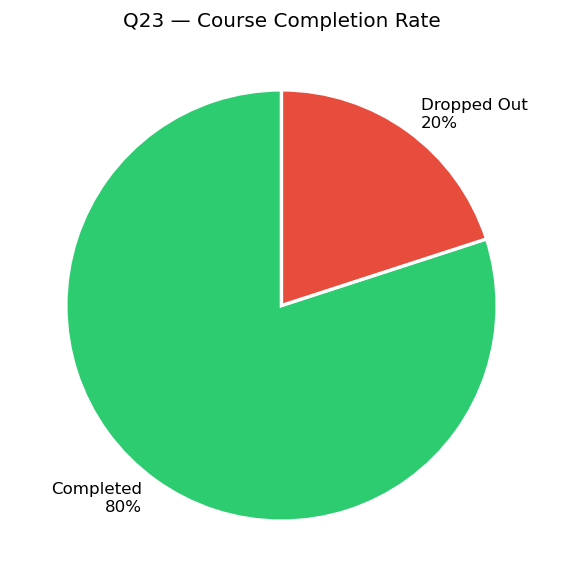

In [24]:
import matplotlib.pyplot as plt

completed   = 20
dropped_out = 5
total       = completed + dropped_out
completion_rate = (completed / total) * 100
dropout_rate    = (dropped_out / total) * 100

print("Course Completion Analysis:")
print(f"  Total Students:  {total}")
print(f"  Completed:       {completed}")
print(f"  Dropped Out:     {dropped_out}")
print()
print(f"  Completion Rate: {completion_rate:.1f}%")
print(f"  Dropout Rate:    {dropout_rate:.1f}%")
print()

status = ("Healthy ✅" if completion_rate >= 80
          else "Needs improvement ⚠️"
          if completion_rate >= 60
          else "Critical ❌")
print(f"  Platform Status: {status}")

# Visualization
plt.figure(figsize=(5, 5))
plt.pie([completed, dropped_out],
        labels=[f'Completed\n{completion_rate:.0f}%',
                f'Dropped Out\n{dropout_rate:.0f}%'],
        colors=['#2ecc71', '#e74c3c'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Q23 — Course Completion Rate')
plt.tight_layout()
plt.show()

### Q24 — Trend Detection

Weekly Score Trend Analysis:
  Scores: [60, 65, 70, 68, 75]

  Week-by-week changes: [5, 5, -2, 7]
  Regression Slope:     3.30
  Trend Direction:      Increasing 📈

Interpretation:
  → Positive slope (3.30) confirms improving trend
  → Week 4 slight dip (-2) but recovered in Week 5 (+7)
  → Overall student is progressing well


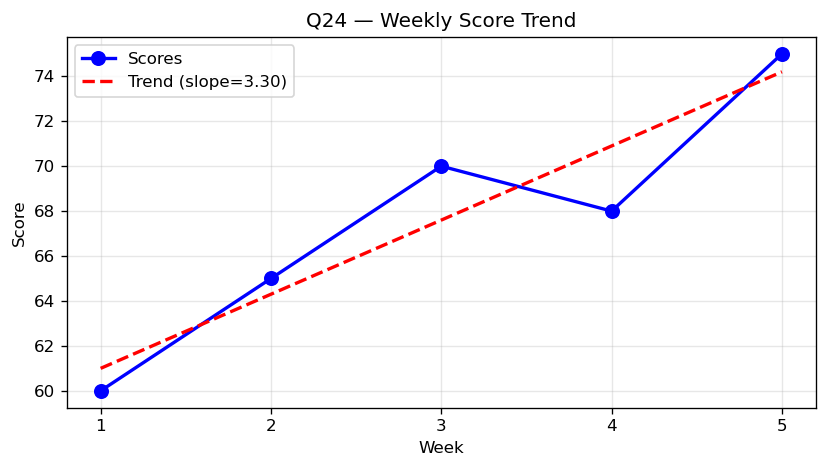

In [25]:
import numpy as np

scores = [60, 65, 70, 68, 75]
weeks  = list(range(1, len(scores) + 1))

slope = np.polyfit(weeks, scores, 1)[0]

trend = ("Increasing 📈" if slope > 1 
         else "Decreasing 📉" if slope < -1 
         else "Stable ➡️")

changes = [scores[i] - scores[i-1] 
           for i in range(1, len(scores))]

print("Weekly Score Trend Analysis:")
print(f"  Scores: {scores}")
print()
print(f"  Week-by-week changes: {changes}")
print(f"  Regression Slope:     {slope:.2f}")
print(f"  Trend Direction:      {trend}")
print()
print("Interpretation:")
print(f"  → Positive slope ({slope:.2f}) confirms improving trend")
print(f"  → Week 4 slight dip (-2) but recovered in Week 5 (+7)")
print(f"  → Overall student is progressing well")

# visualization
plt.figure(figsize=(7, 4))
plt.plot(weeks, scores, 'bo-', 
         linewidth=2, markersize=8, label='Scores')
trend_line = np.poly1d(np.polyfit(weeks, scores, 1))
plt.plot(weeks, trend_line(weeks), 'r--', 
         linewidth=2, label=f'Trend (slope={slope:.2f})')
plt.xlabel('Week')
plt.ylabel('Score')
plt.title('Q24 — Weekly Score Trend')
plt.xticks(weeks)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Q25 — Relative Improvement

Recommendation Model Improvement:
  Old Accuracy:          62%
  New Accuracy:          74%
  Absolute Improvement:  +12%
  Relative Improvement:  +19.35%

Interpretation:
  → Model improved by 19.35% relative to baseline
  → Relative improvement matters more than absolute
  → Going 62%→74% is a bigger win than 88%→100%
     (same +12 absolute, but 19.4% vs 13.6% relative)


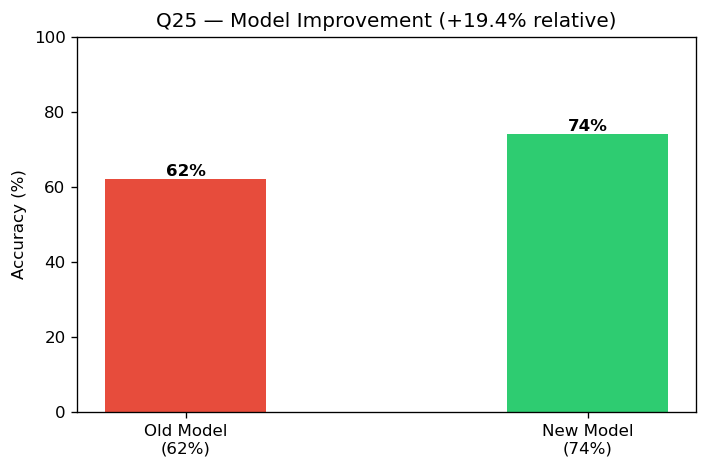

In [26]:
import matplotlib.pyplot as plt

old_accuracy = 62
new_accuracy = 74
absolute_improvement = new_accuracy - old_accuracy
relative_improvement = ((new_accuracy - old_accuracy)
                         / old_accuracy) * 100

print("Recommendation Model Improvement:")
print(f"  Old Accuracy:          {old_accuracy}%")
print(f"  New Accuracy:          {new_accuracy}%")
print(f"  Absolute Improvement:  +{absolute_improvement}%")
print(f"  Relative Improvement:  +{relative_improvement:.2f}%")
print()
print("Interpretation:")
print(f"  → Model improved by {relative_improvement:.2f}% relative to baseline")
print(f"  → Relative improvement matters more than absolute")
print(f"  → Going 62%→74% is a bigger win than 88%→100%")
print(f"     (same +12 absolute, but {relative_improvement:.1f}% vs 13.6% relative)")

# Visualization
plt.figure(figsize=(6, 4))
bars = plt.bar(['Old Model\n(62%)', 'New Model\n(74%)'],
               [old_accuracy, new_accuracy],
               color=['#e74c3c', '#2ecc71'], width=0.4)
plt.ylabel('Accuracy (%)')
plt.title(f'Q25 — Model Improvement (+{relative_improvement:.1f}% relative)')
plt.ylim(0, 100)
for bar, val in zip(bars, [old_accuracy, new_accuracy]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary

| Section | Questions | Topics Covered |
|---------|-----------|----------------|
| **A** | Q1–Q5 | Descriptive Stats, Normalization, Class Imbalance, Linear Regression, Mean Imputation |
| **B** | Q6–Q13 | Logistic Regression, Confusion Matrix, KNN, Decision Trees, MAE, Random Forest, Threshold, Feature Importance |
| **C** | Q14–Q20 | K-Means, Euclidean Distance, Centroid Assignment, Elbow Method, DBSCAN, PCA |
| **D** | Q21–Q25 | Content-Based Filtering, Cosine Similarity, Completion Rate, Trend Detection, Relative Improvement |

All questions solved using Python with NumPy, Pandas, Scikit-learn, and Matplotlib.
